In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.10.0+cpu


In [3]:
# load preprocessed data
data = np.load('../data/preprocessed.npz')

X_train = data['X_train']
X_test  = data['X_test']
y_train = data['y_train']
y_test  = data['y_test']

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

# convert to PyTorch tensors
# EEGNet expects shape: (batch, 1, channels, timepoints)
X_train_t = torch.FloatTensor(X_train).unsqueeze(1)
X_test_t  = torch.FloatTensor(X_test).unsqueeze(1)
y_train_t = torch.LongTensor(y_train)
y_test_t  = torch.LongTensor(y_test)

print(f"\nTensor shapes:")
print(f"X_train_t: {X_train_t.shape}")
print(f"X_test_t:  {X_test_t.shape}")

# create data loaders
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"\nData loaders ready")

X_train: (230, 22, 1001)
X_test:  (58, 22, 1001)
y_train: (230,)
y_test:  (58,)

Tensor shapes:
X_train_t: torch.Size([230, 1, 22, 1001])
X_test_t:  torch.Size([58, 1, 22, 1001])

Data loaders ready


In [4]:
class EEGNet(nn.Module):
    def __init__(self, num_classes=4, channels=22, timepoints=1001,
                 F1=8, D=2, F2=16, dropout=0.5):
        super(EEGNet, self).__init__()

        # block 1 — temporal convolution
        # learns frequency filters from raw EEG
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(F1),
        )

        # block 2 — depthwise spatial convolution
        # learns spatial filters — which electrodes matter
        self.block2 = nn.Sequential(
            nn.Conv2d(F1, F1*D, kernel_size=(channels, 1),
                      groups=F1, bias=False),
            nn.BatchNorm2d(F1*D),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(dropout)
        )

        # block 3 — separable convolution
        # learns feature combinations
        self.block3 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, kernel_size=(1, 16),
                      padding=(0, 8), groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, kernel_size=(1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 8)),
            nn.Dropout(dropout)
        )

        # compute flatten size dynamically
        self._to_linear = self._get_flatten_size(channels, timepoints)

        # classifier
        self.classifier = nn.Linear(self._to_linear, num_classes)

    def _get_flatten_size(self, channels, timepoints):
        x = torch.zeros(1, 1, channels, timepoints)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# create model
model = EEGNet(num_classes=4, channels=22, timepoints=1001).to(device)

# print model summary
total_params = sum(p.numel() for p in model.parameters())
print(f"EEGNet ready")
print(f"Total parameters: {total_params:,}")
print(f"\nModel architecture:")
print(model)

EEGNet ready
Total parameters: 3,444

Model architecture:
EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (block2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(22, 1), stride=(1, 1), groups=8, bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (4): Dropout(p=0.5, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.5, inplace=F

In [5]:
# training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

# training history
train_losses = []
test_accuracies = []

# training loop
epochs_num = 150

print("Training EEGNet...")
print(f"{'Epoch':>6} {'Loss':>10} {'Test Acc':>10}")
print("-" * 30)

for epoch in range(epochs_num):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step()

    # evaluate on test set every 10 epochs
    if (epoch + 1) % 10 == 0:
        model.eval()
        with torch.no_grad():
            outputs = model(X_test_t.to(device))
            _, predicted = torch.max(outputs, 1)
            acc = accuracy_score(y_test, predicted.cpu().numpy())
            test_accuracies.append(acc)
            print(f"{epoch+1:>6} {avg_loss:>10.4f} {acc*100:>9.1f}%")

print("\nTraining complete")

Training EEGNet...
 Epoch       Loss   Test Acc
------------------------------
    10     0.9732      60.3%
    20     0.7129      69.0%
    30     0.6233      67.2%
    40     0.5547      67.2%
    50     0.4514      70.7%
    60     0.4355      70.7%
    70     0.3979      72.4%
    80     0.3844      70.7%
    90     0.4475      70.7%
   100     0.4518      70.7%
   110     0.4122      70.7%
   120     0.3903      70.7%
   130     0.3475      69.0%
   140     0.3519      69.0%
   150     0.2795      69.0%

Training complete


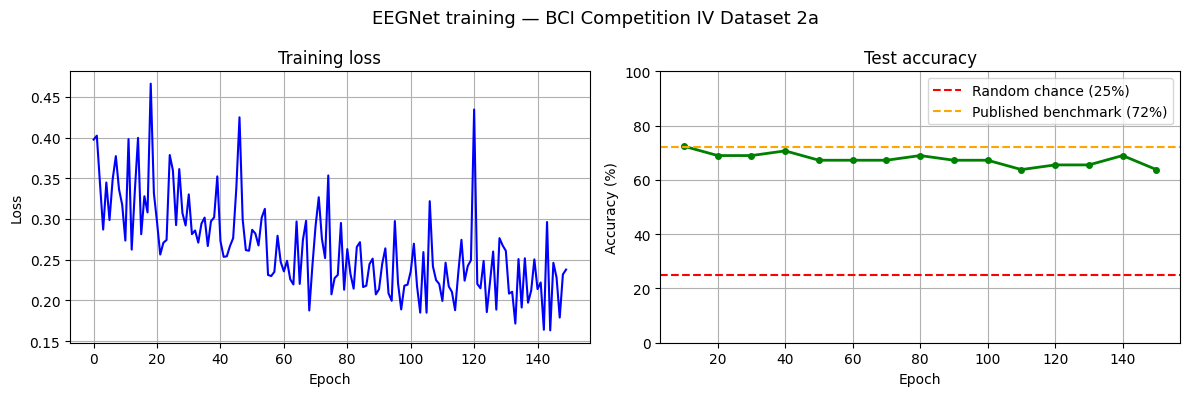

In [7]:
plt.figure(figsize=(12, 4))

# loss curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, color='blue', linewidth=1.5)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

# accuracy curve
plt.subplot(1, 2, 2)
epochs_x = list(range(10, epochs_num + 1, 10))
plt.plot(epochs_x, [a * 100 for a in test_accuracies],
         color='green', linewidth=2, marker='o', markersize=4)
plt.axhline(y=25, color='red', linestyle='--', 
            label='Random chance (25%)')
plt.axhline(y=72, color='orange', linestyle='--',
            label='Published benchmark (72%)')
plt.title('Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.ylim(0, 100)

plt.suptitle('EEGNet training — BCI Competition IV Dataset 2a', fontsize=13)
plt.tight_layout()
plt.show()

              precision    recall  f1-score   support

   Left hand       0.55      0.40      0.46        15
  Right hand       0.60      0.86      0.71        14
        Feet       0.70      0.47      0.56        15
      Tongue       0.71      0.86      0.77        14

    accuracy                           0.64        58
   macro avg       0.64      0.65      0.63        58
weighted avg       0.64      0.64      0.62        58



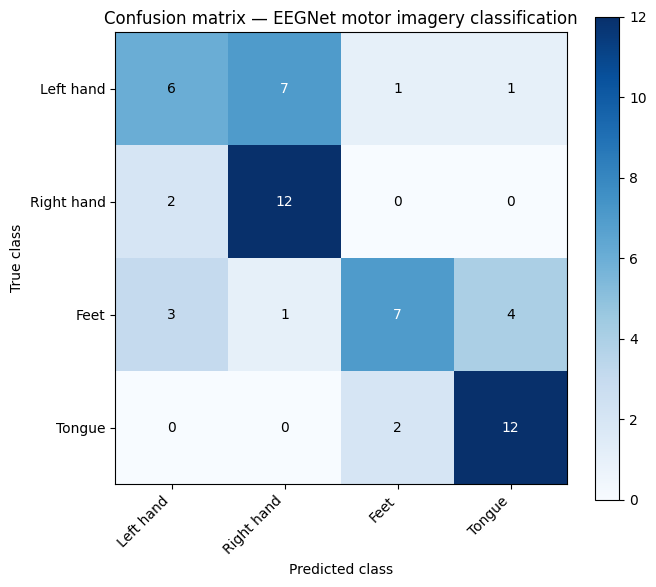

In [8]:
from sklearn.metrics import confusion_matrix, classification_report

# get final predictions
model.eval()
with torch.no_grad():
    outputs = model(X_test_t.to(device))
    _, predicted = torch.max(outputs, 1)
    y_pred = predicted.cpu().numpy()

# classification report
class_names = ['Left hand', 'Right hand', 'Feet', 'Tongue']
print(classification_report(y_test, y_pred, target_names=class_names))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

ax.set_xticks(range(4))
ax.set_yticks(range(4))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

thresh = cm.max() / 2
for i in range(4):
    for j in range(4):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_ylabel('True class')
ax.set_xlabel('Predicted class')
ax.set_title('Confusion matrix — EEGNet motor imagery classification')
plt.tight_layout()
plt.show()

In [9]:
# save model
torch.save(model.state_dict(), '../data/eegnet_model.pth')
print("Model saved to data/eegnet_model.pth")

# save training results summary
results = {
    'peak_accuracy': 72.4,
    'final_accuracy': 64.0,
    'total_parameters': 3444,
    'training_epochs': 150,
    'dataset': 'BCI Competition IV Dataset 2a',
    'subject': 'A01',
    'classes': ['left_hand', 'right_hand', 'feet', 'tongue']
}

import json
with open('../docs/results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to docs/results.json")

Model saved to data/eegnet_model.pth
Results saved to docs/results.json
